## Run

In [2]:
import numpy as np
from fig2_driver import experiment

chi_trp = [1, 2, 3, 4, 5, 10, 20]
# chi_var = list(range(1, 60 + 1, 2))
chi_var = list(range(1, 60 + 1, 2))

res = experiment(
    n=10,
    K=20,
    eps=1e-5,
    k_list=np.linspace(2, 100, 16),
    chi_list=chi_trp,
    chi_var_list=chi_var,
    trials=1,
    seed=0,
    ridge=1e-12,
    dtype=np.float64,
    var_nsamples=500,
    gauss_nsamples=500,
    run_nystrom=False,
)

[build] n=10 K=20 eps=1.00e-05 dtype=<class 'numpy.float64'>
[build] constructing MPO (A + eps*I)
│21│21│21│21│21│21│21│21│21│
●--●--●--●--●--●--●--●--●--●
│  │  │  │  │  │  │  │  │  │
│1│1│2│2│2│2│2│2│2│
▶┈▶┈▶-▶-▶-▶-▶-▶-▶-●
│ │ │ │ │ │ │ │ │ │
[check] trace(A)=2.001024e+01  expected=2.001024e+01
[stats] estimating Var(w^T A w) / tr(A)^2 with pooled rmps samples


KeyboardInterrupt: 

## Plot

In [ ]:
from TNrandNLA.experiments.Figure2_rMPS.fig2_plotting import plot_nystrom

chi_var_list_sorted = sorted([int(c) for c in res["chi_var_list"]])

plot_res = dict(res)
plot_res["dense_nuc_median"]       = res["dense_median"]
plot_res["dense_nuc_p10"]          = res["dense_p10"]
plot_res["dense_nuc_p90"]          = res["dense_p90"]
plot_res["mps_tn_rel_fro_median"]  = res["trp_median"]
plot_res["mps_tn_rel_fro_p10"]     = res["trp_p10"]
plot_res["mps_tn_rel_fro_p90"]     = res["trp_p90"]
plot_res["quad_median_dense_rmps"] = [res["quad_var_median"][c] for c in chi_var_list_sorted]

fig, axs = plot_nystrom(plot_res, plot_nystrom=False)
fig.savefig("figures/Figure2.pdf", format="pdf", bbox_inches="tight")

## (Optional) Save

In [4]:
import pickle
from datetime import datetime

save_file = True

if save_file:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"data/fig2_results_{timestamp}.pkl"
    with open(filename, 'wb') as file:
        pickle.dump(res, file)
    print(f"Saved to {filename}")

Saved to data/fig2_results_20260603_184935.pkl


## Load then Plot

Loading data/collated.pkl
X-axis ticks: [10, 30, 50, 70, 90]
v_theory: [5.80751486e+04 2.71380994e+02 5.11790400e+01 2.14821122e+01
 1.23543344e+01 8.33413319e+00 6.17356037e+00 4.85770165e+00
 3.98499981e+00 3.36951512e+00 2.91489798e+00 2.56682283e+00
 2.29257865e+00 2.07140659e+00 1.88955470e+00 1.73758135e+00
 1.60880556e+00 1.49837616e+00 1.40269110e+00 1.31902316e+00
 1.24527175e+00 1.17979412e+00 1.12128803e+00 1.06870850e+00
 1.02120768e+00 9.78090823e-01 9.38783385e-01 9.02806300e-01
 8.69757037e-01 8.39294995e-01]


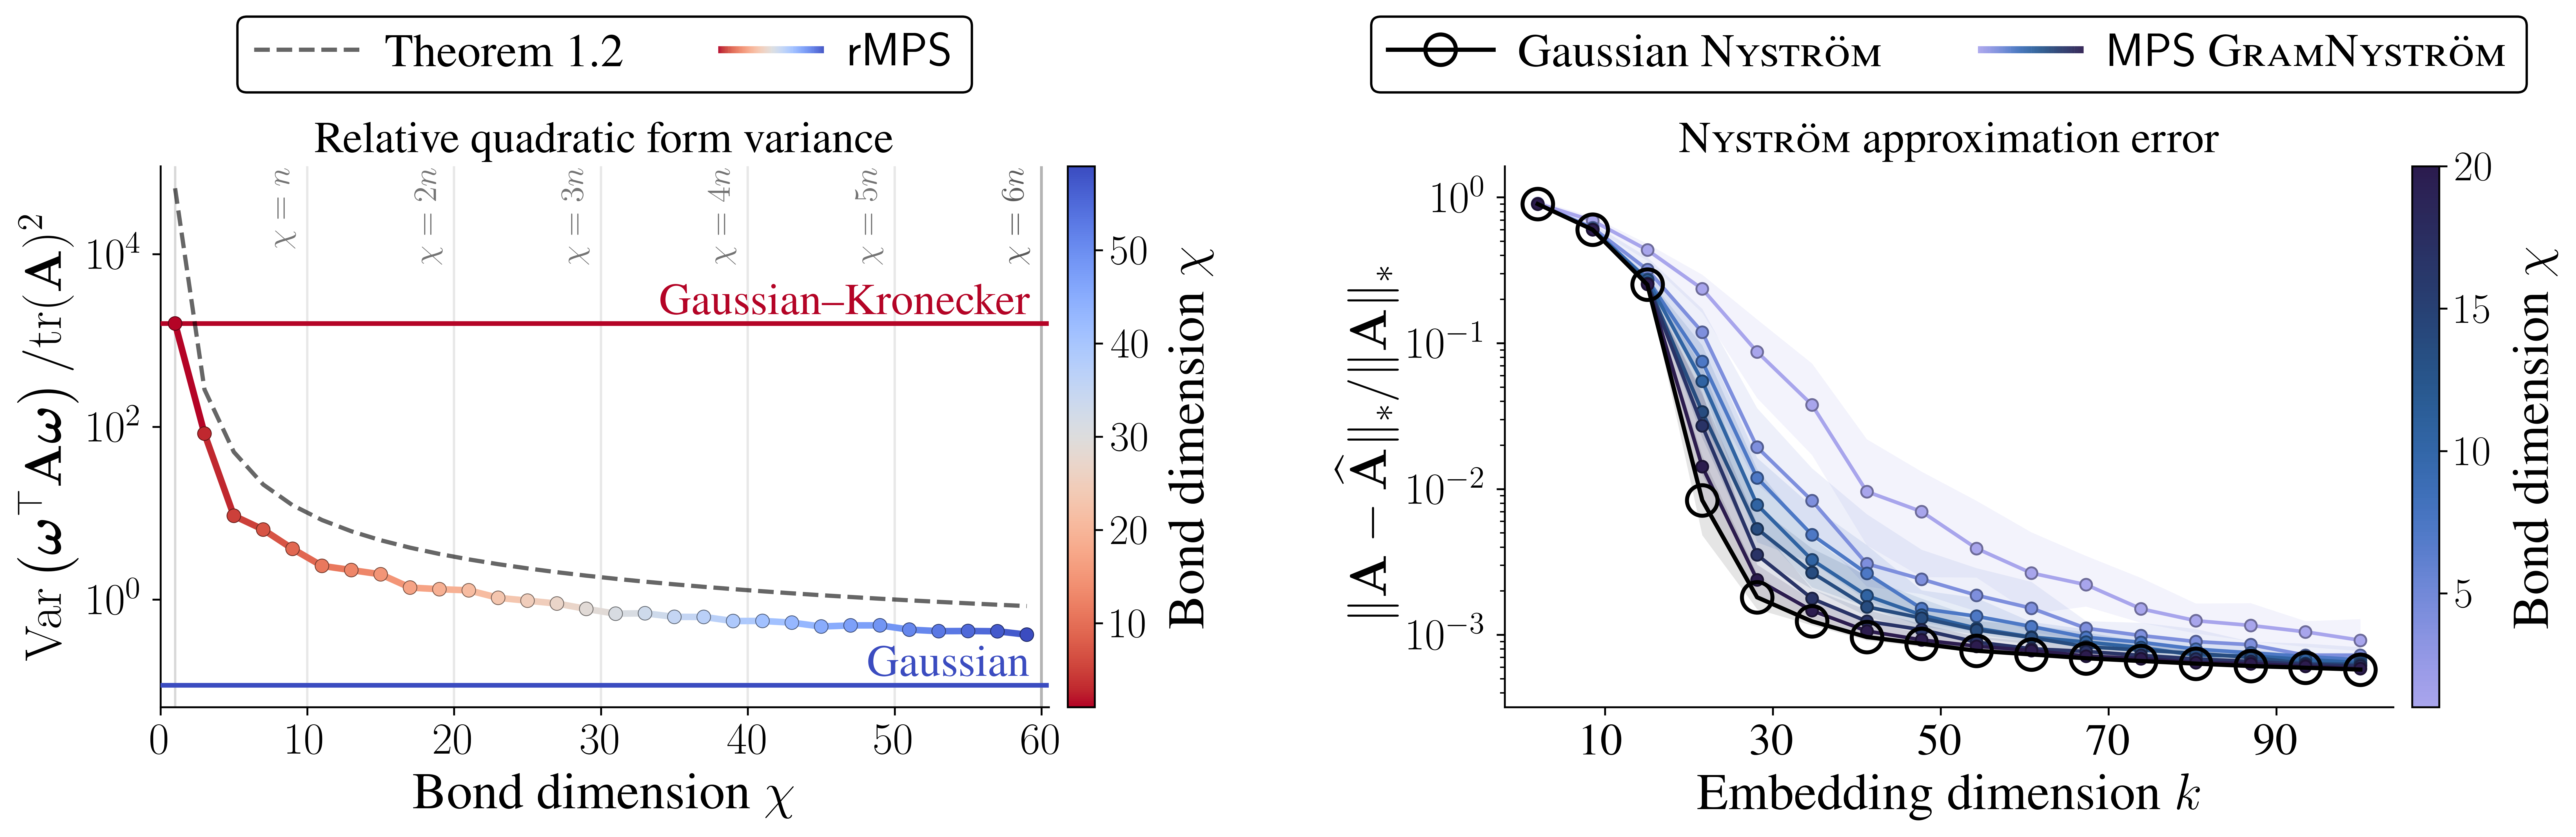

In [ ]:
import pickle
import glob

files = sorted(glob.glob("data/collated.pkl"))
filename = files[-1]  # most recent save
print(f"Loading {filename}")
with open(filename, 'rb') as f:
    res = pickle.load(f)

from TNrandNLA.experiments.Figure2_rMPS.fig2_plotting import plot_nystrom

chi_var_list_sorted = sorted([int(c) for c in res["chi_var_list"]])

plot_res = dict(res)
plot_res["dense_nuc_median"]       = res["dense_median"]
plot_res["dense_nuc_p10"]          = res["dense_p10"]
plot_res["dense_nuc_p90"]          = res["dense_p90"]
plot_res["mps_tn_rel_fro_median"]  = res["trp_median"]
plot_res["mps_tn_rel_fro_p10"]     = res["trp_p10"]
plot_res["mps_tn_rel_fro_p90"]     = res["trp_p90"]
plot_res["quad_median_dense_rmps"] = [res["quad_var_median"][c] for c in chi_var_list_sorted]

fig, axs = plot_nystrom(plot_res)
fig.savefig("figures/Figure2.pdf", format="pdf", bbox_inches="tight")